In [12]:
from utils.constantes import DATA_CLEAN_PATH
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 

In [3]:
archivo_clean_path = DATA_CLEAN_PATH / "usu_clean_individual.csv"
df = pd.read_csv(archivo_clean_path, delimiter=",",low_memory=False)
df

,CODUSU,ANO4,TRIMESTRE,NRO_HOGAR,COMPONENTE,H15,REGION,MAS_500,AGLOMERADO,PONDERA,...,IDECCFR,RDECCFR,GDECCFR,PDECCFR,ADECCFR,PONDIH,CH04_str,NIVEL_ED_str,CONDICION_LABORAL,UNIVERSITARIO
0,TQRMNOPUTHLMKQCDEGGFB00852588,2024,1,1,3,1,42,S,10,439,...,12.0,12,12.0,NaN,12,0,femenino,secundario incompleto,ocupado dependiente,0
1,TQRMNOPUTHLMKQCDEGGFB00852588,2024,1,1,4,1,42,S,10,439,...,12.0,12,12.0,NaN,12,0,femenino,superior o universitario,inactivo,1
2,TQRMNOPUTHLMKQCDEGGFB00852588,2024,1,1,5,0,42,S,10,439,...,12.0,12,12.0,NaN,12,0,femenino,sin informacion,fuera de categoria,0
3,TQRMNOPPWHLLKRCDEGGFB00852574,2024,1,1,1,1,42,S,10,675,...,6.0,6,6.0,NaN,6,1610,masculino,secundario completo,ocupado dependiente,0
4,TQRMNOPPWHLLKRCDEGGFB00852574,2024,1,1,2,1,42,S,10,675,...,6.0,6,6.0,NaN,6,1610,femenino,secundario completo,ocupado dependiente,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
93196,TQRMNORQQHJLLMCDEGKDB00866867,2024,2,1,3,0,43,N,14,152,...,6.0,5,NaN,7.0,7,489,masculino,sin informacion,fuera de categoria,0
93197,TQRMNORQQHJLLMCDEGKDB00866867,2024,2,1,4,0,43,N,14,152,...,6.0,5,NaN,7.0,7,489,femenino,primario incompleto,fuera de categoria,0
93198,TQRMNORRTHJKLNCDEGKDB00866868,2024,2,1,1,1,43,N,14,174,...,8.0,7,NaN,8.0,9,283,femenino,primario completo,inactivo,0
93199,TQSMNOPYSHMOKMCDEFMDB00866869,2024,2,1,1,1,43,N,6,183,...,3.0,2,NaN,3.0,2,272,femenino,secundario incompleto,ocupado dependiente,0


In [33]:
df['PP09A_ESP'] = df['PP09A_ESP'].fillna(0)
df['PP09A_ESP']

0        0
1        0
2        0
3        0
4        0
        ..
93196    0
93197    0
93198    0
93199    0
93200    0
Name: PP09A_ESP, Length: 93201, dtype: object

In [5]:
df_anios =  sorted(df["ANO4"].astype(str).unique())
df_trimestres = sorted(df['TRIMESTRE'].astype(str).unique())
# anio_seleccionado = todos 


In [ ]:
# df con columnas de edad y sexo 
df_filtrado = df[["PONDERA","CH04", "CH06"]].copy()


rango_anios = range(0,101,10)
etiquetas =  [f"{i}-{i+9}" for i in rango_anios[:-1]] 

df_filtrado["CH06"] = pd.to_numeric(df_filtrado["CH06"], errors="coerce")
df_filtrado["grupos_edad"] = pd.cut(df_filtrado["CH06"],bins=rango_anios , labels=etiquetas)

df_filtrado["CH04"] = df_filtrado["CH04"].apply(lambda x: "M" if x == 1 else "F")
df_filtrado = df_filtrado.groupby(["grupos_edad","CH04"])["PONDERA"].sum().reset_index()

df_filtrado


In [25]:
df_hombres = df_filtrado[df_filtrado["CH04"] == 'M'].copy()
df_mujeres = df_filtrado[df_filtrado["CH04"] == 'F'].copy()
df_hombres

,grupos_edad,CH04,PONDERA
1,0-9,M,4468719
3,10-19,M,5073789
5,20-29,M,4270368
7,30-39,M,3935704
9,40-49,M,3962847
11,50-59,M,2984955
13,60-69,M,2155131
15,70-79,M,1324054
17,80-89,M,426707
19,90-99,M,39488


C:\Users\Usuario\AppData\Local\Temp\ipykernel_20008\2999010365.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df_hombres["grupos_edad"])
C:\Users\Usuario\AppData\Local\Temp\ipykernel_20008\2999010365.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(labels_y)


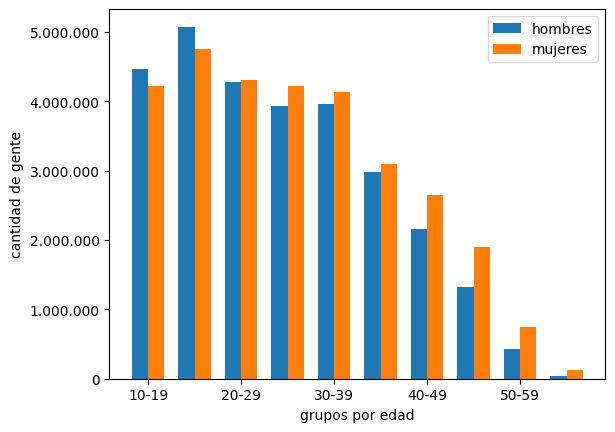

In [36]:
x = np.arange(len(df_hombres.index))
ancho = 0.35 
valores_y = [0,1000000,2000000,3000000,4000000,5000000]
labels_y = ["0","1.000.000","2.000.000","3.000.000","4.000.000","5.000.000"]

fig, ax = plt.subplots()

ax.bar(x - ancho / 2 , df_hombres["PONDERA"], width=ancho , label="hombres")
ax.bar(x + ancho / 2 , df_mujeres["PONDERA"], width=ancho , label="mujeres")

ax.set_xlabel("grupos por edad") 
ax.set_ylabel("cantidad de gente") 


ax.set_xticklabels(df_hombres["grupos_edad"])
ax.set_yticklabels(labels_y)
ax.legend()
